# Project 2: MovieLens 100K
### Marc Fridson | CUNY SPS | DATA 620

---

This notebook analyzes the **MovieLens 100K** dataset as a bipartite (two-mode) network: 943 users and 1,682 movies connected by 100,000 ratings, with all ties running between groups, never within them. The network is reduced using the **island method** (de Nooy, Mrvar & Batagelj, Ch. 4), which progressively raises a threshold on edge weights to isolate cohesive subgraphs where the weakest internal bond exceeds any external connection. Community detection and centrality analysis are then applied to characterize each group.

## 1. Data Loading and Bipartite Network Construction

In [7]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.algorithms import bipartite
from collections import defaultdict
from community import community_louvain
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

# Download and extract MovieLens 100K
import urllib.request, zipfile, os
if not os.path.exists('ml-100k'):
    urllib.request.urlretrieve('https://files.grouplens.org/datasets/movielens/ml-100k.zip', 'ml-100k.zip')
    with zipfile.ZipFile('ml-100k.zip', 'r') as z:
        z.extractall('.')

# Load data
ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id','movie_id','rating','timestamp'])

genre_names = ['unknown','Action','Adventure','Animation',"Children's",'Comedy',
               'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
               'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western']
movie_cols = ['movie_id','title','release_date','video_date','url'] + genre_names
movies = pd.read_csv('ml-100k/u.item', sep='|', names=movie_cols, encoding='latin-1')
users = pd.read_csv('ml-100k/u.user', sep='|', names=['user_id','age','gender','occupation','zip'])

# Filter to positive ratings (4-5 stars) for meaningful affinity signal
positive = ratings[ratings['rating'] >= 4].copy()

# Build bipartite graph
B = nx.Graph()
for uid in positive['user_id'].unique():
    B.add_node(f"u_{uid}", bipartite=0, node_type='user')
for mid in positive['movie_id'].unique():
    title = movies.loc[movies['movie_id'] == mid, 'title'].values
    B.add_node(f"m_{mid}", bipartite=1, node_type='movie', title=title[0] if len(title) else f"Movie {mid}", movie_id=mid)
for _, row in positive.iterrows():
    B.add_edge(f"u_{row['user_id']}", f"m_{row['movie_id']}", rating=row['rating'])

user_nodes = {n for n, d in B.nodes(data=True) if d['bipartite'] == 0}
movie_nodes = set(B) - user_nodes

print(f"Bipartite graph: {len(user_nodes)} users, {len(movie_nodes)} movies, {B.number_of_edges():,} edges")
print(f"Density: {bipartite.density(B, user_nodes):.4f}")
print(f"Is bipartite: {nx.is_bipartite(B)}")

Bipartite graph: 942 users, 1447 movies, 55,375 edges
Density: 0.0406
Is bipartite: True


## 2. One-Mode Projections and Island Method

Projecting onto each mode gives weighted one-mode networks: users connected by shared positively-rated movies, movies connected by shared users. The island method then raises a threshold on these weights to isolate the strongest connected subgraphs at each level.

In [3]:
# Weighted projections
user_proj = bipartite.weighted_projected_graph(B, user_nodes)
movie_proj = bipartite.weighted_projected_graph(B, movie_nodes)

for name, proj in [('User', user_proj), ('Movie', movie_proj)]:
    weights = [d['weight'] for _, _, d in proj.edges(data=True)]
    print(f"{name} projection: {proj.number_of_nodes()} nodes, {proj.number_of_edges():,} edges, "
          f"weight range {min(weights)}-{max(weights)}, median {np.median(weights):.0f}")

User projection: 942 nodes, 382,442 edges, weight range 1-179, median 5
Movie projection: 1447 nodes, 460,019 edges, weight range 1-349, median 2


In [4]:
def island_method(G, min_island_size=3):
    """Island method: find cohesive subgraphs at progressively higher weight thresholds."""
    weights = sorted(set(d['weight'] for _, _, d in G.edges(data=True)), reverse=True)
    islands, seen = [], []

    for threshold in weights:
        H = nx.Graph()
        H.add_nodes_from(G.nodes(data=True))
        H.add_edges_from((u, v, d) for u, v, d in G.edges(data=True) if d['weight'] >= threshold)

        for comp in nx.connected_components(H):
            sub = H.subgraph(comp)
            if len(comp) < min_island_size or sub.number_of_edges() == 0:
                continue
            frozen = frozenset(comp)
            if any(frozen == s or frozen.issubset(s) for s in seen):
                continue
            islands.append({
                'threshold': threshold, 'nodes': comp, 'size': len(comp),
                'edges': sub.number_of_edges(), 'density': nx.density(sub),
                'avg_weight': np.mean([d['weight'] for _, _, d in sub.edges(data=True)])
            })
            seen.append(frozen)

    islands.sort(key=lambda x: (-x['threshold'], -x['size']))
    return islands

user_islands = island_method(user_proj, min_island_size=3)
movie_islands = island_method(movie_proj, min_island_size=3)
print(f"User islands: {len(user_islands)}, Movie islands: {len(movie_islands)}\n")

# Top movie islands
print("=== Top Movie Islands ===\n")
for i, island in enumerate(movie_islands[:6]):
    mids = [int(n.split('_')[1]) for n in island['nodes']]
    island_movies = movies[movies['movie_id'].isin(mids)]
    genre_counts = island_movies[genre_names].sum().sort_values(ascending=False)
    top_genres = ', '.join([f"{g}: {int(c)}" for g, c in genre_counts[genre_counts > 0].head(4).items()])

    print(f"Island {i+1} (threshold={island['threshold']}, {island['size']} movies, density={island['density']:.3f}):")
    print(f"  Genres: {top_genres}")
    for _, m in island_movies.head(5).iterrows():
        genres = [g for g in genre_names if m[g] == 1]
        print(f"  {m['title']} [{', '.join(genres)}]")
    print()

# Top user islands
print("=== Top User Islands ===\n")
for i, island in enumerate(user_islands[:4]):
    uids = [int(n.split('_')[1]) for n in island['nodes']]
    demo = users[users['user_id'].isin(uids)]
    island_ratings = positive[positive['user_id'].isin(uids)]
    top_movies = island_ratings['movie_id'].value_counts().head(5)

    print(f"Island {i+1} (threshold={island['threshold']}, {island['size']} users):")
    print(f"  Gender: {demo['gender'].value_counts().to_dict()}, Avg age: {demo['age'].mean():.0f}, "
          f"Top occupations: {demo['occupation'].value_counts().head(2).to_dict()}")
    for mid, count in top_movies.items():
        title = movies.loc[movies['movie_id'] == mid, 'title'].values[0]
        print(f"  {title} ({count}/{len(uids)} users)")
    print()

User islands: 132, Movie islands: 166

=== Top Movie Islands ===

Island 1 (threshold=293, 3 movies, density=0.667):
  Genres: Action: 3, Adventure: 3, Sci-Fi: 2, Romance: 2
  Star Wars (1977) [Action, Adventure, Romance, Sci-Fi, War]
  Raiders of the Lost Ark (1981) [Action, Adventure]
  Return of the Jedi (1983) [Action, Adventure, Romance, Sci-Fi, War]

Island 2 (threshold=274, 4 movies, density=0.500):
  Genres: Action: 4, Adventure: 4, Sci-Fi: 3, Romance: 3
  Star Wars (1977) [Action, Adventure, Romance, Sci-Fi, War]
  Empire Strikes Back, The (1980) [Action, Adventure, Drama, Romance, Sci-Fi, War]
  Raiders of the Lost Ark (1981) [Action, Adventure]
  Return of the Jedi (1983) [Action, Adventure, Romance, Sci-Fi, War]

Island 3 (threshold=267, 5 movies, density=0.400):
  Genres: Action: 4, Adventure: 4, Sci-Fi: 3, Romance: 3
  Star Wars (1977) [Action, Adventure, Romance, Sci-Fi, War]
  Fargo (1996) [Crime, Drama, Thriller]
  Empire Strikes Back, The (1980) [Action, Adventure, Dr

## 3. Visualization and Community Validation

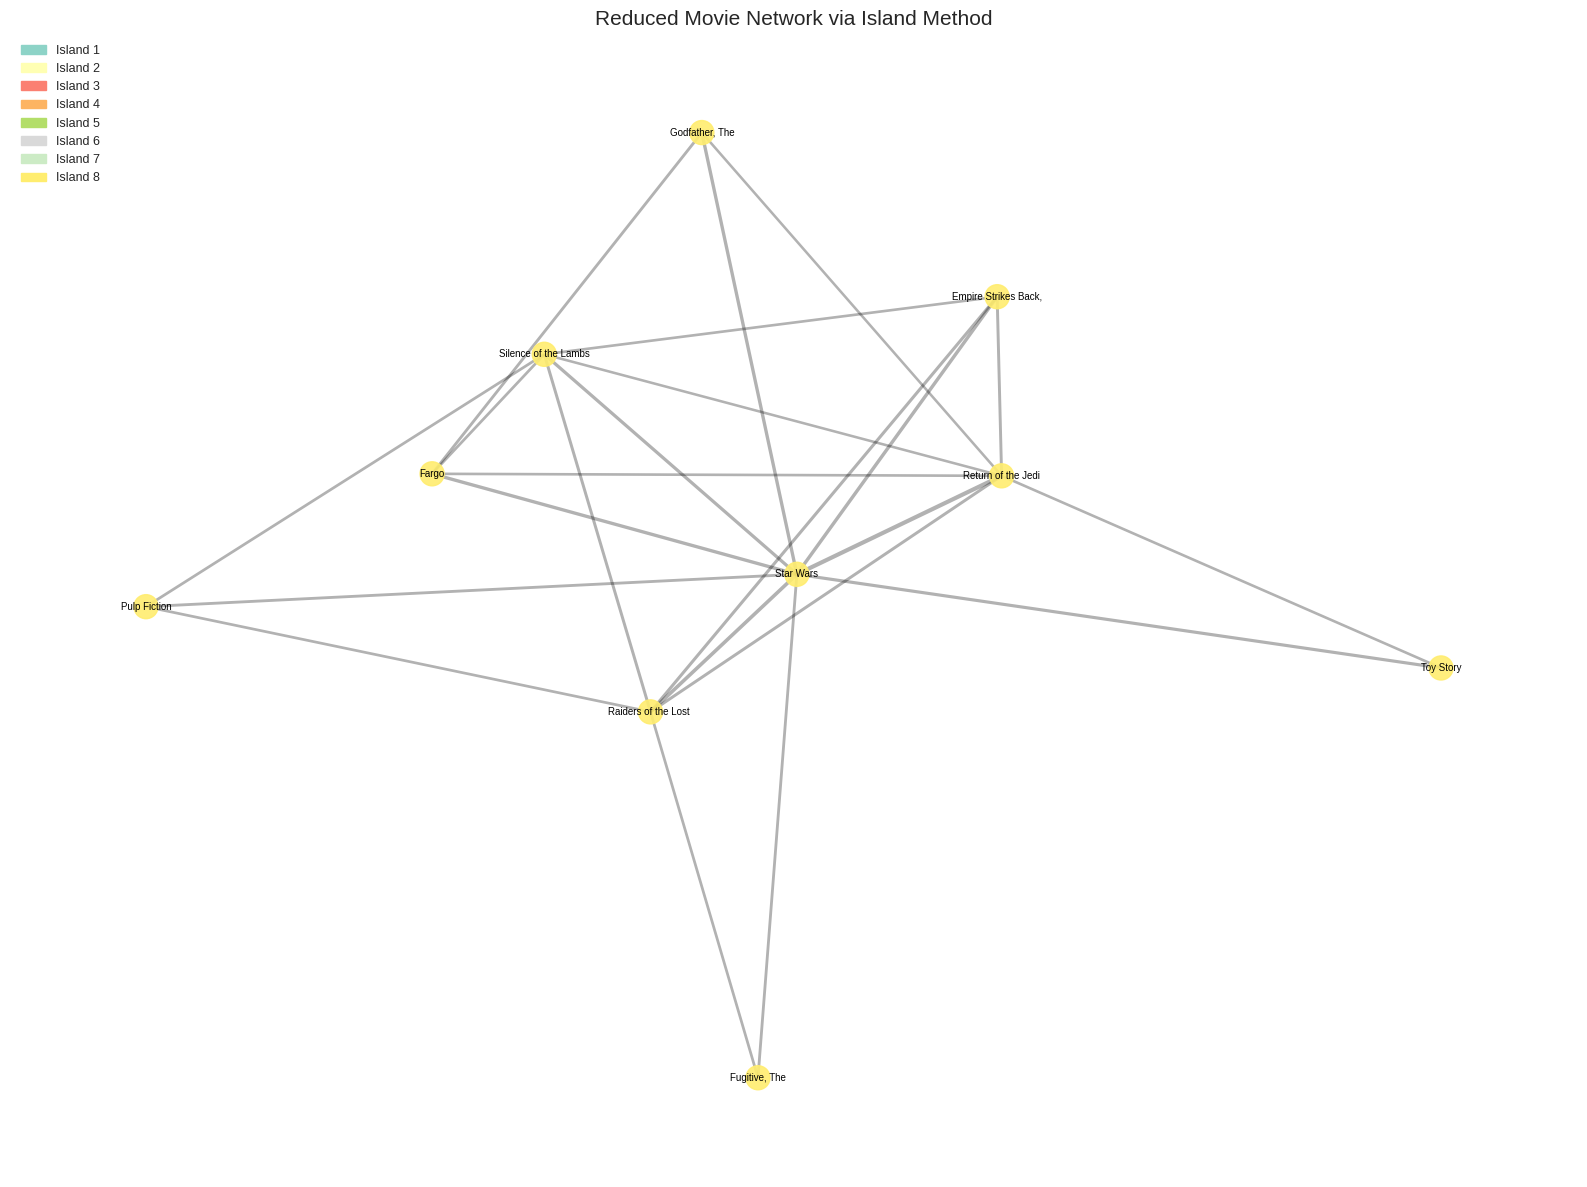

In [5]:
# Visualize top movie islands as reduced network
top_n = min(8, len(movie_islands))
node_island_map = {}
for i, island in enumerate(movie_islands[:top_n]):
    for node in island['nodes']:
        node_island_map[node] = i

reduced = movie_proj.subgraph(set(node_island_map.keys())).copy()
weight_thresh = np.percentile([d['weight'] for _, _, d in reduced.edges(data=True)], 50)
reduced.remove_edges_from([(u, v) for u, v, d in reduced.edges(data=True) if d['weight'] < weight_thresh])
reduced.remove_nodes_from(list(nx.isolates(reduced)))
for n in list(node_island_map):
    if n not in reduced:
        del node_island_map[n]

colors = plt.cm.Set3(np.linspace(0, 1, top_n))
labels = {n: movies.loc[movies['movie_id'] == int(n.split('_')[1]), 'title'].values[0].split('(')[0].strip()[:20]
          for n in reduced.nodes() if len(movies.loc[movies['movie_id'] == int(n.split('_')[1]), 'title'].values) > 0}

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(reduced, k=2, seed=42, iterations=50)
edge_w = [d['weight'] for _, _, d in reduced.edges(data=True)]
max_w = max(edge_w) if edge_w else 1

nx.draw_networkx_edges(reduced, pos, alpha=0.3, width=[0.5 + 2.5*(w/max_w) for w in edge_w], ax=ax)
nx.draw_networkx_nodes(reduced, pos, node_color=[colors[node_island_map[n]] for n in reduced.nodes()],
                        node_size=300, alpha=0.9, ax=ax)
nx.draw_networkx_labels(reduced, pos, labels, font_size=7, ax=ax)
ax.legend(handles=[mpatches.Patch(color=colors[i], label=f'Island {i+1}') for i in range(min(top_n, 8))],
          loc='upper left', fontsize=9)
ax.set_title('Reduced Movie Network via Island Method', fontsize=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('reduced_movie_network.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Louvain community detection and centrality on strong-tie movie network
movie_weights = [d['weight'] for _, _, d in movie_proj.edges(data=True)]
movie_p90 = np.percentile(movie_weights, 90)

movie_strong = nx.Graph()
movie_strong.add_nodes_from(movie_proj.nodes(data=True))
movie_strong.add_edges_from((u, v, d) for u, v, d in movie_proj.edges(data=True) if d['weight'] >= movie_p90)
movie_strong.remove_nodes_from(list(nx.isolates(movie_strong)))

movie_communities = community_louvain.best_partition(movie_strong, weight='weight', random_state=42)
movie_mod = community_louvain.modularity(movie_communities, movie_strong, weight='weight')
print(f"Strong-tie movie network: {movie_strong.number_of_nodes()} nodes, {movie_strong.number_of_edges()} edges")
print(f"Louvain communities: {len(set(movie_communities.values()))}, Modularity: {movie_mod:.3f}\n")

degree_c = nx.degree_centrality(movie_strong)
between_c = nx.betweenness_centrality(movie_strong, weight='weight')

cent_df = pd.DataFrame({'node': list(degree_c.keys()), 'degree': list(degree_c.values()),
                         'betweenness': [between_c[n] for n in degree_c.keys()]})
cent_df['movie_id'] = cent_df['node'].apply(lambda x: int(x.split('_')[1]))
cent_df = cent_df.merge(movies[['movie_id','title']], on='movie_id')

print("Top 10 by Degree Centrality:")
for _, r in cent_df.nlargest(10, 'degree').iterrows():
    print(f"  {r['title']:<45} deg={r['degree']:.3f}  btw={r['betweenness']:.3f}")

print("\nTop 5 by Betweenness (Bridge Films):")
for _, r in cent_df.nlargest(5, 'betweenness').iterrows():
    print(f"  {r['title']:<45} deg={r['degree']:.3f}  btw={r['betweenness']:.3f}")

Strong-tie movie network: 623 nodes, 48133 edges
Louvain communities: 3, Modularity: 0.114

Top 10 by Degree Centrality:
  Star Wars (1977)                              deg=0.937  btw=0.017
  Fargo (1996)                                  deg=0.881  btw=0.042
  Raiders of the Lost Ark (1981)                deg=0.863  btw=0.015
  Silence of the Lambs, The (1991)              deg=0.854  btw=0.011
  Return of the Jedi (1983)                     deg=0.838  btw=0.009
  Godfather, The (1972)                         deg=0.823  btw=0.009
  Pulp Fiction (1994)                           deg=0.820  btw=0.005
  Empire Strikes Back, The (1980)               deg=0.817  btw=0.007
  Shawshank Redemption, The (1994)              deg=0.783  btw=0.004
  Toy Story (1995)                              deg=0.773  btw=0.010

Top 5 by Betweenness (Bridge Films):
  Fargo (1996)                                  deg=0.881  btw=0.042
  Star Wars (1977)                              deg=0.937  btw=0.017
  Raiders of 

## 4. Inferences

**Users:** The 132 user islands represent taste communities, not demographic clusters. The top islands are mixtures of genders, ages, and occupations, what binds them is behavioral similarity in rating volume and genre preference, not who they are. Louvain found 3 broader communities: one younger/programmer-heavy converging on Star Wars and action films, another older/educator-heavy around Fargo, Godfather, and Casablanca.

**Movies:** The 166 movie islands peel back from universal to niche. The top island (threshold 293) is the Star Wars trilogy, the most universally co-loved cluster. Lower thresholds surface genre-specific groupings in drama, comedy, and thriller. Star Wars has the highest degree centrality (0.937), but Fargo leads in betweenness (0.042), making it the key bridge film connecting blockbuster and art-house taste communities.

**Overall:** The island method reduced 55,375 bipartite edges and 460K+ projected edges to interpretable core clusters at multiple scales, without arbitrary cutoffs. Taste in movies is structurally organized: distinct user communities, distinct movie clusters, and bridge films like Fargo that connect them.

---

**References**

de Nooy, W., Mrvar, A., & Batagelj, V. (2018). *Exploratory Social Network Analysis with Pajek* (3rd ed.). Cambridge University Press.

Harper, F. M., & Konstan, J. A. (2015). The MovieLens Datasets: History and Context. *ACM Transactions on Interactive Intelligent Systems*, 5(4), 1–19.